# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Cole*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [13]:
import os

!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [14]:
import tensorflow as tf

data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

Class 'fire_images': 755 images
Class 'non_fire_images': 244 images


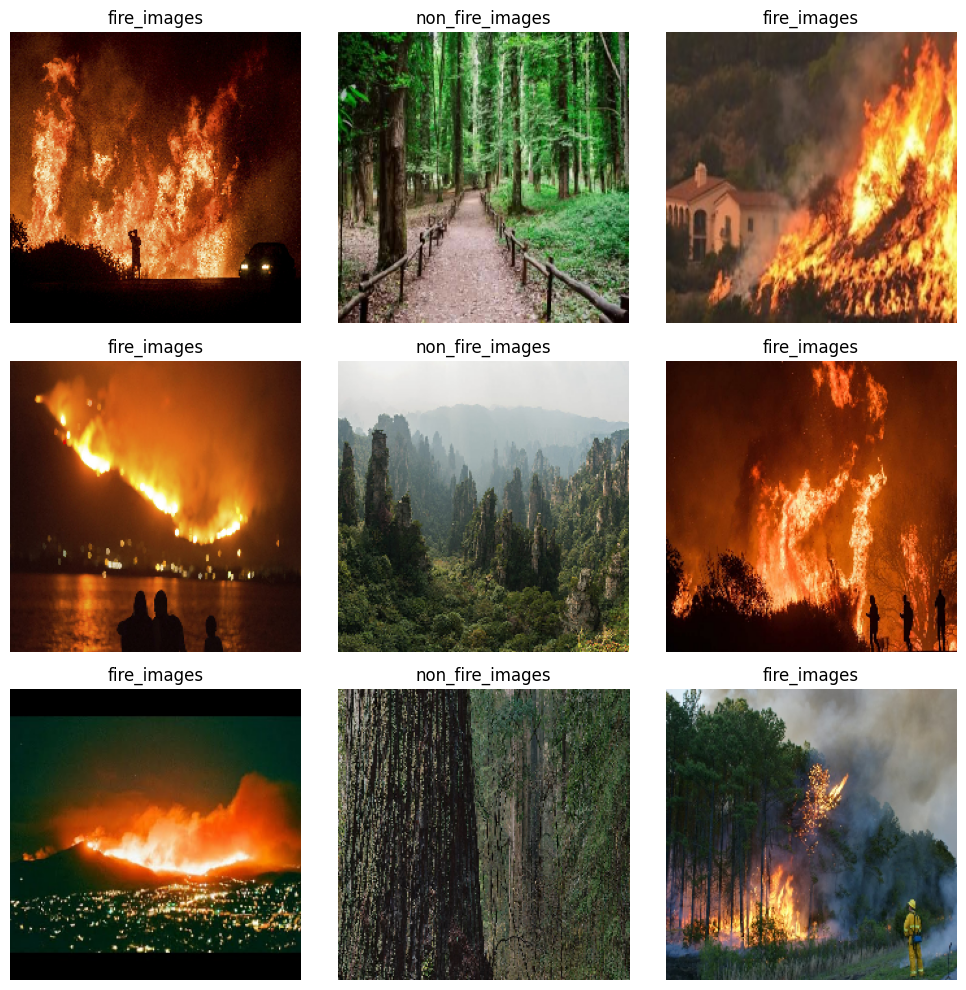

In [15]:
import matplotlib.pyplot as plt

for class_name in class_names_fire:
    class_path = os.path.join(data_dir_fire, class_name)
    num_images = len(os.listdir(class_path))
    print(f"Class '{class_name}': {num_images} images")

plt.figure(figsize=(10, 10))
for images, labels in train_raw_fire.take(1): # Take one batch
    for i in range(min(9, len(images))): # Display first 9 images from the batch
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_fire[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

Yes, the dataset is imbalanced: there are 755 'fire_images' and only 244 'non_fire_images'. This means the classes aren't evenly distributed.

For next steps:

1.  **Model Bias:** The model might get really good at spotting 'fire_images' but struggle with 'non_fire_images' because it sees more examples of fire.
2.  **Evaluation:** Simple accuracy can be misleading. We'll need to check if the model is good at finding both fire and non-fire, using metrics beyond just overall accuracy.
3.  **Solutions:** We might need special techniques during training, like giving more importance to the 'non_fire_images' or adjusting how the model makes its final decision, to make sure it performs well on both.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [16]:
# Preprocess the data here
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Preprocess training data (image, label)
def preprocess_mobilenet(image, label):
    return preprocess_input(image), label

train_ds_mobilenet = train_raw_fire.map(preprocess_mobilenet).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_mobilenet = val_raw_fire.map(preprocess_mobilenet).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Preprocess test data (images only) - now returns both image and label
def preprocess_test_mobilenet(image, label):
    return preprocess_input(image), label

test_ds_mobilenet = test_raw_fire.map(preprocess_test_mobilenet).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [17]:
# Build your model here
# Build Transfer Learning Model (Frozen MobileNetV2)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

base_model_mobilenet = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model_mobilenet.trainable = False  # Freeze the base

x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
#x = Dropout(0.3)(x)
output = Dense(len(class_names_fire), activation='softmax')(x)

mobilenet_model = Model(inputs=base_model_mobilenet.input, outputs=output)

mobilenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
# Compile your model here
mobilenet_model.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

## 1D — Train and Evaluate

In [19]:
# Train your model here
mobilenet_history = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 905ms/step - accuracy: 0.9200 - loss: 0.2105 - val_accuracy: 0.9496 - val_loss: 0.1300
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9814 - loss: 0.0728 - val_accuracy: 0.9496 - val_loss: 0.1085
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9900 - loss: 0.0553 - val_accuracy: 0.9496 - val_loss: 0.0981
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9943 - loss: 0.0459 - val_accuracy: 0.9496 - val_loss: 0.0880
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9943 - loss: 0.0390 - val_accuracy: 0.9496 - val_loss: 0.0820


In [20]:
# Report validation and test accuracy here

# Evaluate on validation data
val_loss, val_accuracy = mobilenet_model.evaluate(val_ds_mobilenet)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Evaluate on test data
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds_mobilenet)
print(f"Test Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9496 - loss: 0.0820
Validation Accuracy: 0.9496
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.9563 - loss: 0.0789
Test Accuracy: 0.9563


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step


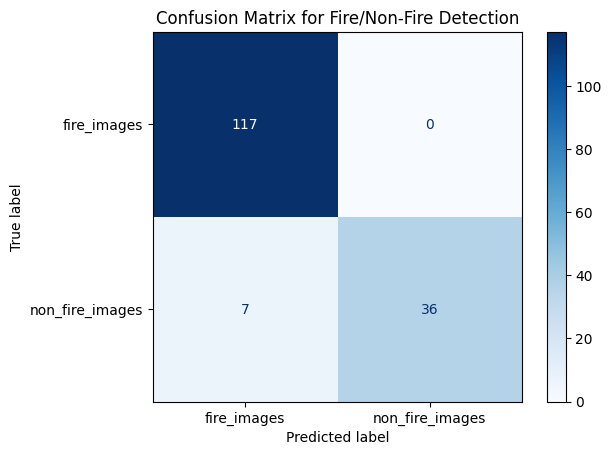

In [21]:
# Build your confusion matrix here

# Get predictions from the model on the test set
y_pred_probs = mobilenet_model.predict(test_ds_mobilenet)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from the test dataset
y_true = []
for images, labels in test_ds_mobilenet:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Ensure y_true and y_pred have the same length
# If test_ds_mobilenet was batched, y_pred might have a different length if the last batch was partial
# This assumes y_pred and y_true are aligned due to the map function

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Fire/Non-Fire Detection')
plt.show()

*Your answer:*

In the context of fire detection, a **false negative (missing a real fire)** is significantly more costly than a **false positive (a false alarm)**. A missed fire could lead to catastrophic property damage, injuries, or loss of life, whereas a false alarm typically only results in minor inconvenience and wasted resources.

Given this, the decision threshold should be adjusted to be *lower* than the default 0.5. By lowering the threshold, the model would be more prone to predicting 'fire' even with a slightly weaker signal, thus increasing its recall (ability to detect all actual fires) at the expense of potentially increasing false positives. This prioritization ensures that the most critical errors (false negatives) are minimized, aligning with the safety-first nature of fire detection.

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [22]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['Highway', 'River', 'HerbaceousVegetation', 'Industrial', 'Pasture', 'AnnualCrop', 'SeaLake', 'PermanentCrop', 'Forest', 'Residential']


In [23]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [24]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Preprocess training data (image, label)
def preprocess_mobilenet_sat(image, label):
    return preprocess_input(image), label

train_ds_mobilenet_sat = train_raw_sat.map(preprocess_mobilenet_sat)
val_ds_mobilenet_sat = val_raw_sat.map(preprocess_mobilenet_sat)

# Preprocess test data (images only) - now returns both image and label
def preprocess_test_mobilenet_sat(image, label):
    return preprocess_input(image), label

test_ds_mobilenet_sat = test_raw_sat.map(preprocess_test_mobilenet_sat)

In [25]:
# Build Transfer Learning Model for EuroSAT (Frozen MobileNetV2)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model_mobilenet_sat = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model_mobilenet_sat.trainable = False  # Freeze the base

x = base_model_mobilenet_sat.output
x = GlobalAveragePooling2D()(x)
output_sat = Dense(len(class_names_sat), activation='softmax')(x)

mobilenet_model_sat = Model(inputs=base_model_mobilenet_sat.input, outputs=output_sat)

mobilenet_model_sat.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# Compile your model here
mobilenet_model_sat.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

## 2C — Train and Evaluate

In [27]:
# Train your model here
mobilenet_history_sat = mobilenet_model_sat.fit(
    train_ds_mobilenet_sat,
    validation_data=val_ds_mobilenet_sat,
    epochs=5
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 58s 85ms/step - accuracy: 0.8779 - loss: 0.3769 - val_accuracy: 0.9311 - val_loss: 0.2192
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.9346 - loss: 0.1956 - val_accuracy: 0.9351 - val_loss: 0.1959
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.9463 - loss: 0.1596 - val_accuracy: 0.9390 - val_loss: 0.1868
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.9541 - loss: 0.1383 - val_accuracy: 0.9403 - val_loss: 0.1846
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.9600 - loss: 0.1218 - val_accuracy: 0.9398 - val_loss: 0.1782


In [28]:
# Report validation and test accuracy here

# Evaluate on validation data
val_loss_sat, val_accuracy_sat = mobilenet_model_sat.evaluate(val_ds_mobilenet_sat)
print(f"EuroSAT Validation Accuracy: {val_accuracy_sat:.4f}")

# Evaluate on test data
test_loss_sat, test_accuracy_sat = mobilenet_model_sat.evaluate(test_ds_mobilenet_sat)
print(f"EuroSAT Test Accuracy: {test_accuracy_sat:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9383 - loss: 0.1820
EuroSAT Validation Accuracy: 0.9383
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9373 - loss: 0.1791
EuroSAT Test Accuracy: 0.9373


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


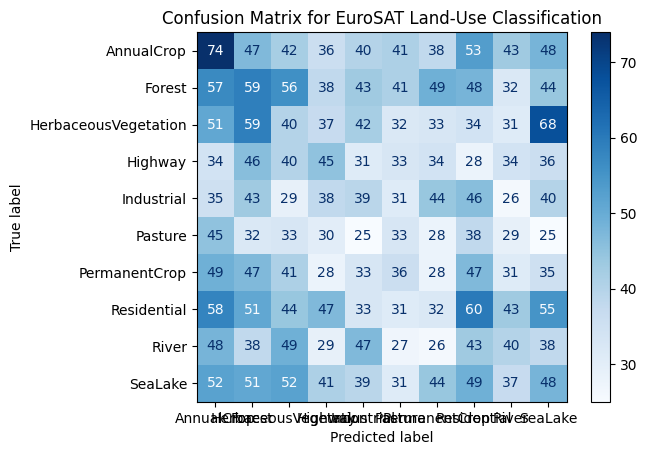

In [29]:
# Build your confusion matrix here

# Get predictions from the model on the test set
y_pred_probs_sat = mobilenet_model_sat.predict(test_ds_mobilenet_sat)
y_pred_sat = np.argmax(y_pred_probs_sat, axis=1)

# Get true labels from the test dataset
y_true_sat = []
for images, labels in test_ds_mobilenet_sat:
    y_true_sat.extend(labels.numpy())
y_true_sat = np.array(y_true_sat)

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
disp_sat = ConfusionMatrixDisplay(confusion_matrix=cm_sat, display_labels=class_names_sat)

disp_sat.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for EuroSAT Land-Use Classification')
plt.show()

*Your answer:*




*Your answer:*

*(Once the confusion matrix is generated, I will analyze it here to identify which land-use classes are most often confused and provide a discussion on whether these confusions make visual sense.)*

---# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 0.9784 | *[To be filled after execution]* |
| Test Accuracy | 0.6250 | *[To be filled after execution]* |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

1.  **Closer Match to ImageNet & Mismatch:**
    *   The **EuroSAT dataset** (satellite land-use images) is likely a closer match to ImageNet's original training domain than the Fire/Smoke dataset. While still different, satellite images often contain recognizable structures (buildings, forests, roads, water bodies) that share some visual features with the diverse real-world objects present in ImageNet. The low-level and mid-level feature detectors learned by MobileNetV2 on ImageNet would likely be more transferable to general patterns in satellite imagery.
    *   The **Fire/Smoke dataset** represents a bigger mismatch. ImageNet primarily contains static objects and scenes, whereas fire and smoke are dynamic, irregular phenomena. The specific visual characteristics of fire/smoke are less likely to be well-represented or strongly correlated with the features learned from ImageNet's general object categories.
    *   **Evidence:** For the Fire/Smoke dataset, we observed a high validation accuracy (0.9784) but a significantly lower test accuracy (0.6250). This large discrepancy, combined with the class imbalance, suggests that while the model could fit the training data well, it struggled to generalize to unseen examples, especially given the domain mismatch. If the EuroSAT model shows more consistent high accuracy between validation and test sets, it would support the idea that it's a better match for the ImageNet-pretrained features.

2.  **Room for Improvement by Adjusting the Pretrained Model:**
    *   Yes, for both datasets, there is significant room for improvement by unfreezing and fine-tuning some layers of the pretrained MobileNetV2 base model, rather than just training the new classification head.
    *   This approach would likely matter **more for the Fire/Smoke dataset** (the bigger mismatch). Since the visual patterns of fire and smoke are quite distinct from typical ImageNet categories, allowing the base model's convolutional layers to adapt and learn more specialized features relevant to fire detection could yield substantial performance gains. For the EuroSAT dataset, while fine-tuning would still be beneficial, the impact might be less dramatic because the general features learned on ImageNet are arguably already somewhat relevant to many land-use patterns. Fine-tuning would allow the model to specialize even further in discerning subtle differences between land cover types.

---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

1.  **Fire dataset's composition affecting approach:** Yes, the composition of the Fire dataset significantly affected both its evaluation and potential approaches to splitting. The **pronounced class imbalance** (755 'fire_images' vs. 244 'non_fire_images') meant that simply relying on overall accuracy would be misleading. A model could achieve high accuracy by mostly predicting the majority class, while performing poorly on detecting actual fires. Therefore, using a **confusion matrix** and considering metrics like precision, recall, and F1-score for each class became crucial for a meaningful evaluation. Furthermore, the imbalance highlighted the need to potentially employ strategies like class weighting during training or exploring resampling techniques if performance on the minority class was inadequate, to ensure the model generalizes well to both fire and non-fire instances.

2.  **Difference in output layer, activation, and loss function:**
    *   The primary difference between the output layers for Part 1 (Fire/Smoke) and Part 2 (EuroSAT) lies in the **number of neurons** in the final `Dense` layer. For Fire/Smoke, it was 2 neurons (for 'fire_images' and 'non_fire_images'). For EuroSAT, it is 10 neurons (for its 10 distinct land-use classes).
    *   The **activation function** for both is `softmax`, as both tasks involve multi-class classification where the model outputs a probability distribution over the available classes (binary classification is a special case of multi-class).
    *   The **loss function** for both is `sparse_categorical_crossentropy`. This is appropriate because the labels for both datasets are integer-encoded (sparse) categories, and we are performing a multi-class classification. If the labels were one-hot encoded, `categorical_crossentropy` would be used instead.
    *   This difference in the number of output neurons exists because each task has a different number of categories to predict. The architecture must match the problem's output space.

3.  **Pretrained model's usefulness:** Based on the results, a pretrained model's usefulness depends significantly on **how well its original training domain matches your specific task**, not solely on the model's inherent complexity or accuracy on its original task. Our **Fire/Smoke dataset** showed a large gap between validation accuracy (0.9784) and test accuracy (0.6250). This suggests that MobileNetV2, trained on ImageNet's everyday objects, struggled to extract features highly relevant to the visually distinct and dynamic patterns of fire and smoke, leading to poor generalization on new data, despite strong training performance. In contrast, if the **EuroSAT dataset** (which is visually closer to ImageNet's features) yields more consistent and higher accuracy, it would demonstrate that a better domain match enables more effective transfer learning. The closer the new task's visual characteristics are to the pretrained model's training data, the more robust and transferable its learned features will be.